In [20]:
import pandas as pd

df = pd.read_csv("Credit_card.csv")
labels = pd.read_csv("Credit_card_label.csv")


---
### 2. Проанализируйте исходные данные. Проведите предобработку, при необходимости заполните пропуски или удалить не важную информацию. Категориальные признаки замените на числовые.

In [21]:
df = df.merge(labels, on="Ind_ID")

df = df.drop(columns=["Ind_ID"])

df = pd.get_dummies(df, drop_first=True)

df = df.fillna(df.median(numeric_only=True))

display(df.head())

print("Количество пропусков:", df.isna().sum().sum())

,CHILDREN,Annual_income,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Family_Members,label,...,Type_Occupation_Laborers,Type_Occupation_Low-skill Laborers,Type_Occupation_Managers,Type_Occupation_Medicine staff,Type_Occupation_Private service staff,Type_Occupation_Realty agents,Type_Occupation_Sales staff,Type_Occupation_Secretaries,Type_Occupation_Security staff,Type_Occupation_Waiters/barmen staff
0,0,180000.0,-18772.0,365243,1,0,0,0,2,1,...,False,False,False,False,False,False,False,False,False,False
1,0,315000.0,-13557.0,-586,1,1,1,0,2,1,...,False,False,False,False,False,False,False,False,False,False
2,0,315000.0,-15661.5,-586,1,1,1,0,2,1,...,False,False,False,False,False,False,False,False,False,False
3,0,166500.0,-13557.0,-586,1,1,1,0,2,1,...,False,False,False,False,False,False,False,False,False,False
4,0,315000.0,-13557.0,-586,1,1,1,0,2,1,...,False,False,False,False,False,False,False,False,False,False


Количество пропусков: 0


---
### 3. Выделите из данных вектор меток У и матрицу признаков Х.

In [22]:
X = df.drop(columns=["label"])
Y = df["label"]


---
### 4. Разделите набор данных на обучающую и тестовую выборки

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print("Обучающая выборка:", X_train.shape, Y_train.shape)
print("Тестовая выборка:", X_test.shape, Y_test.shape)

Обучающая выборка: (1238, 45) (1238,)
Тестовая выборка: (310, 45) (310,)


---
### 5. На обучающей выборке обучите модели дерева решений и k-ближайших соседей, рассчитайте точность моделей.


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#### Дерево решений

In [25]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, Y_train)

tree_pred = tree.predict(X_test)
tree_accuracy = accuracy_score(Y_test, tree_pred)

print("Accuracy дерева решений:", tree_accuracy)

Accuracy дерева решений: 0.8709677419354839


#### K ближайших соседей

In [26]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, Y_train)

knn_pred = knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(Y_test, knn_pred)

print("Accuracy KNN:", knn_accuracy)

Accuracy KNN: 0.8741935483870967


#### F мера

In [27]:
from sklearn.metrics import f1_score

tree_f1 = f1_score(Y_test, tree_pred)
knn_f1 = f1_score(Y_test, knn_pred)

print("F1 дерева:", tree_f1)
print("F1 KNN:", knn_f1)

F1 дерева: 0.4444444444444444
F1 KNN: 0.1702127659574468


---
### 6. Подберите наилучшие параметры моделей (например, глубину для дерева решений, количество соседей для алгоритма knn). Можно построить график ошибок и увидеть при каких параметрах ошибки наименьшие, или использовать другие способы.


In [28]:
from sklearn.metrics import accuracy_score

#### Дерево решений

In [29]:
tree_results = []

for depth in range(1, 18):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, Y_train)

    pred = model.predict(X_test)
    accuracy = accuracy_score(Y_test, pred)

    tree_results.append((depth, accuracy, pred))

print("Дерево:")
best_tree = max(tree_results, key=lambda x: x[1])
print(best_tree[0], " ", best_tree[1])

Дерево:
7   0.8870967741935484


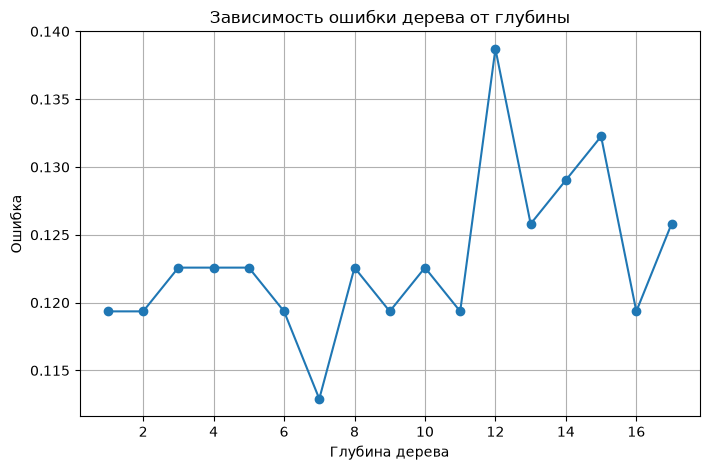

In [30]:
import matplotlib.pyplot as plt

tree_errors = [(depth, 1 - accuracy) for depth, accuracy, _ in tree_results]


plt.figure(figsize=(8, 5))
plt.plot(
    [x[0] for x in tree_errors],
    [x[1] for x in tree_errors],
    marker="o"
)
plt.xlabel("Глубина дерева")
plt.ylabel("Ошибка")
plt.title("Зависимость ошибки дерева от глубины")
plt.grid()
plt.show()


#### KNN

In [31]:
knn_results = []

for k in range(1, 16):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, Y_train)

    pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(Y_test, pred)

    knn_results.append((k, accuracy, pred))

print("KNN:")
best_knn = max(knn_results, key=lambda x: x[1])
print(best_knn[0], " ", best_knn[1])

KNN:
1   0.9096774193548387


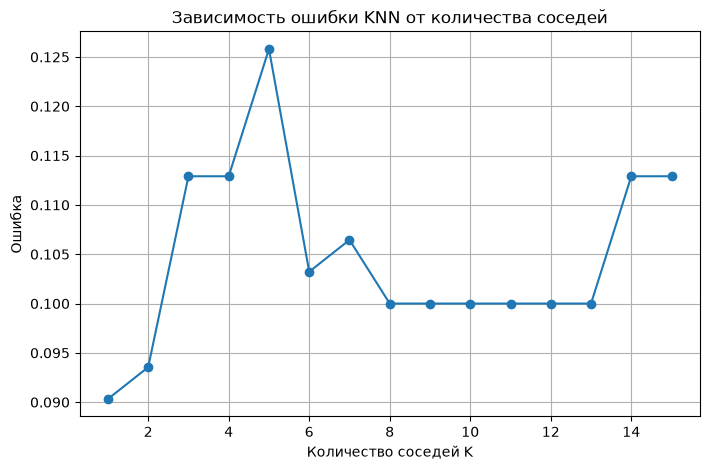

In [32]:
knn_errors = [(k, 1 - accuracy) for k, accuracy, _ in knn_results]
plt.figure(figsize=(8, 5))
plt.plot(
    [x[0] for x in knn_errors],
    [x[1] for x in knn_errors],
    marker="o"
)
plt.xlabel("Количество соседей K")
plt.ylabel("Ошибка")
plt.title("Зависимость ошибки KNN от количества соседей")
plt.grid()
plt.show()

---
### 7. Рассчитайте матрицу ошибок (confusion matrix) для каждой модели.


In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

|TN|FP|
|--|--|
|FN|TP|

#### Матрица ошибок дерева

Матрица ошибок дерева:
[[268   7]
 [ 28   7]]


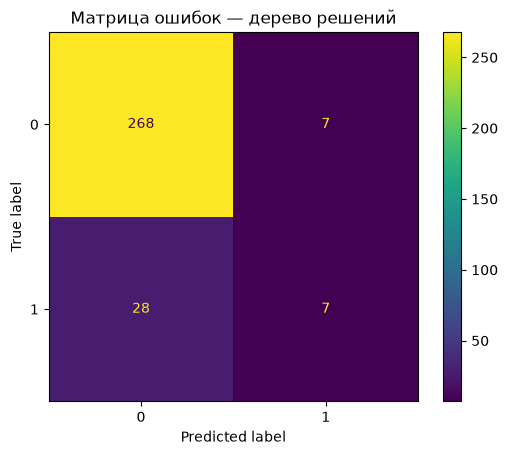

In [34]:
tree_cm = confusion_matrix(Y_test, best_tree[2])

print("Матрица ошибок дерева:")
print(tree_cm)

ConfusionMatrixDisplay(tree_cm).plot()
plt.title("Матрица ошибок — дерево решений")
plt.show()

#### Матрица ошибок KNN

Матрица ошибок KNN:
[[263  12]
 [ 16  19]]


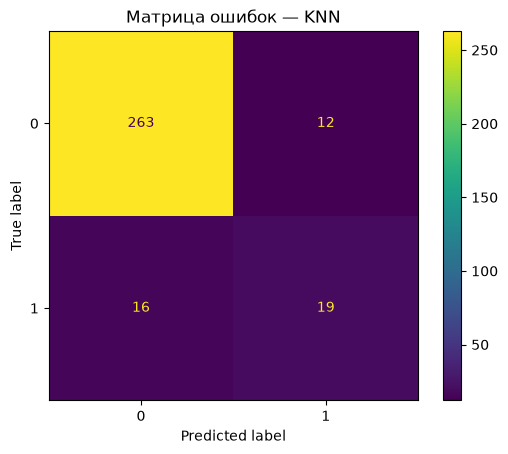

In [35]:
knn_cm = confusion_matrix(Y_test, best_knn[2])

print("Матрица ошибок KNN:")
print(knn_cm)

ConfusionMatrixDisplay(knn_cm).plot()
plt.title("Матрица ошибок — KNN")
plt.show()

---
### 8. Выберите лучшую модель.


Лучшая модель: KNN

---
### 9*. Визуализируйте полученную модель дерева решений (при визуализации желательно уменьшить глубину дерева,  что бы рисунок был читаемым, или сохранить в отдельный файл). Обратите внимание на изменение коэффициента gini в узлах дерева. Что он обозначает?

In [36]:
from sklearn.tree import plot_tree

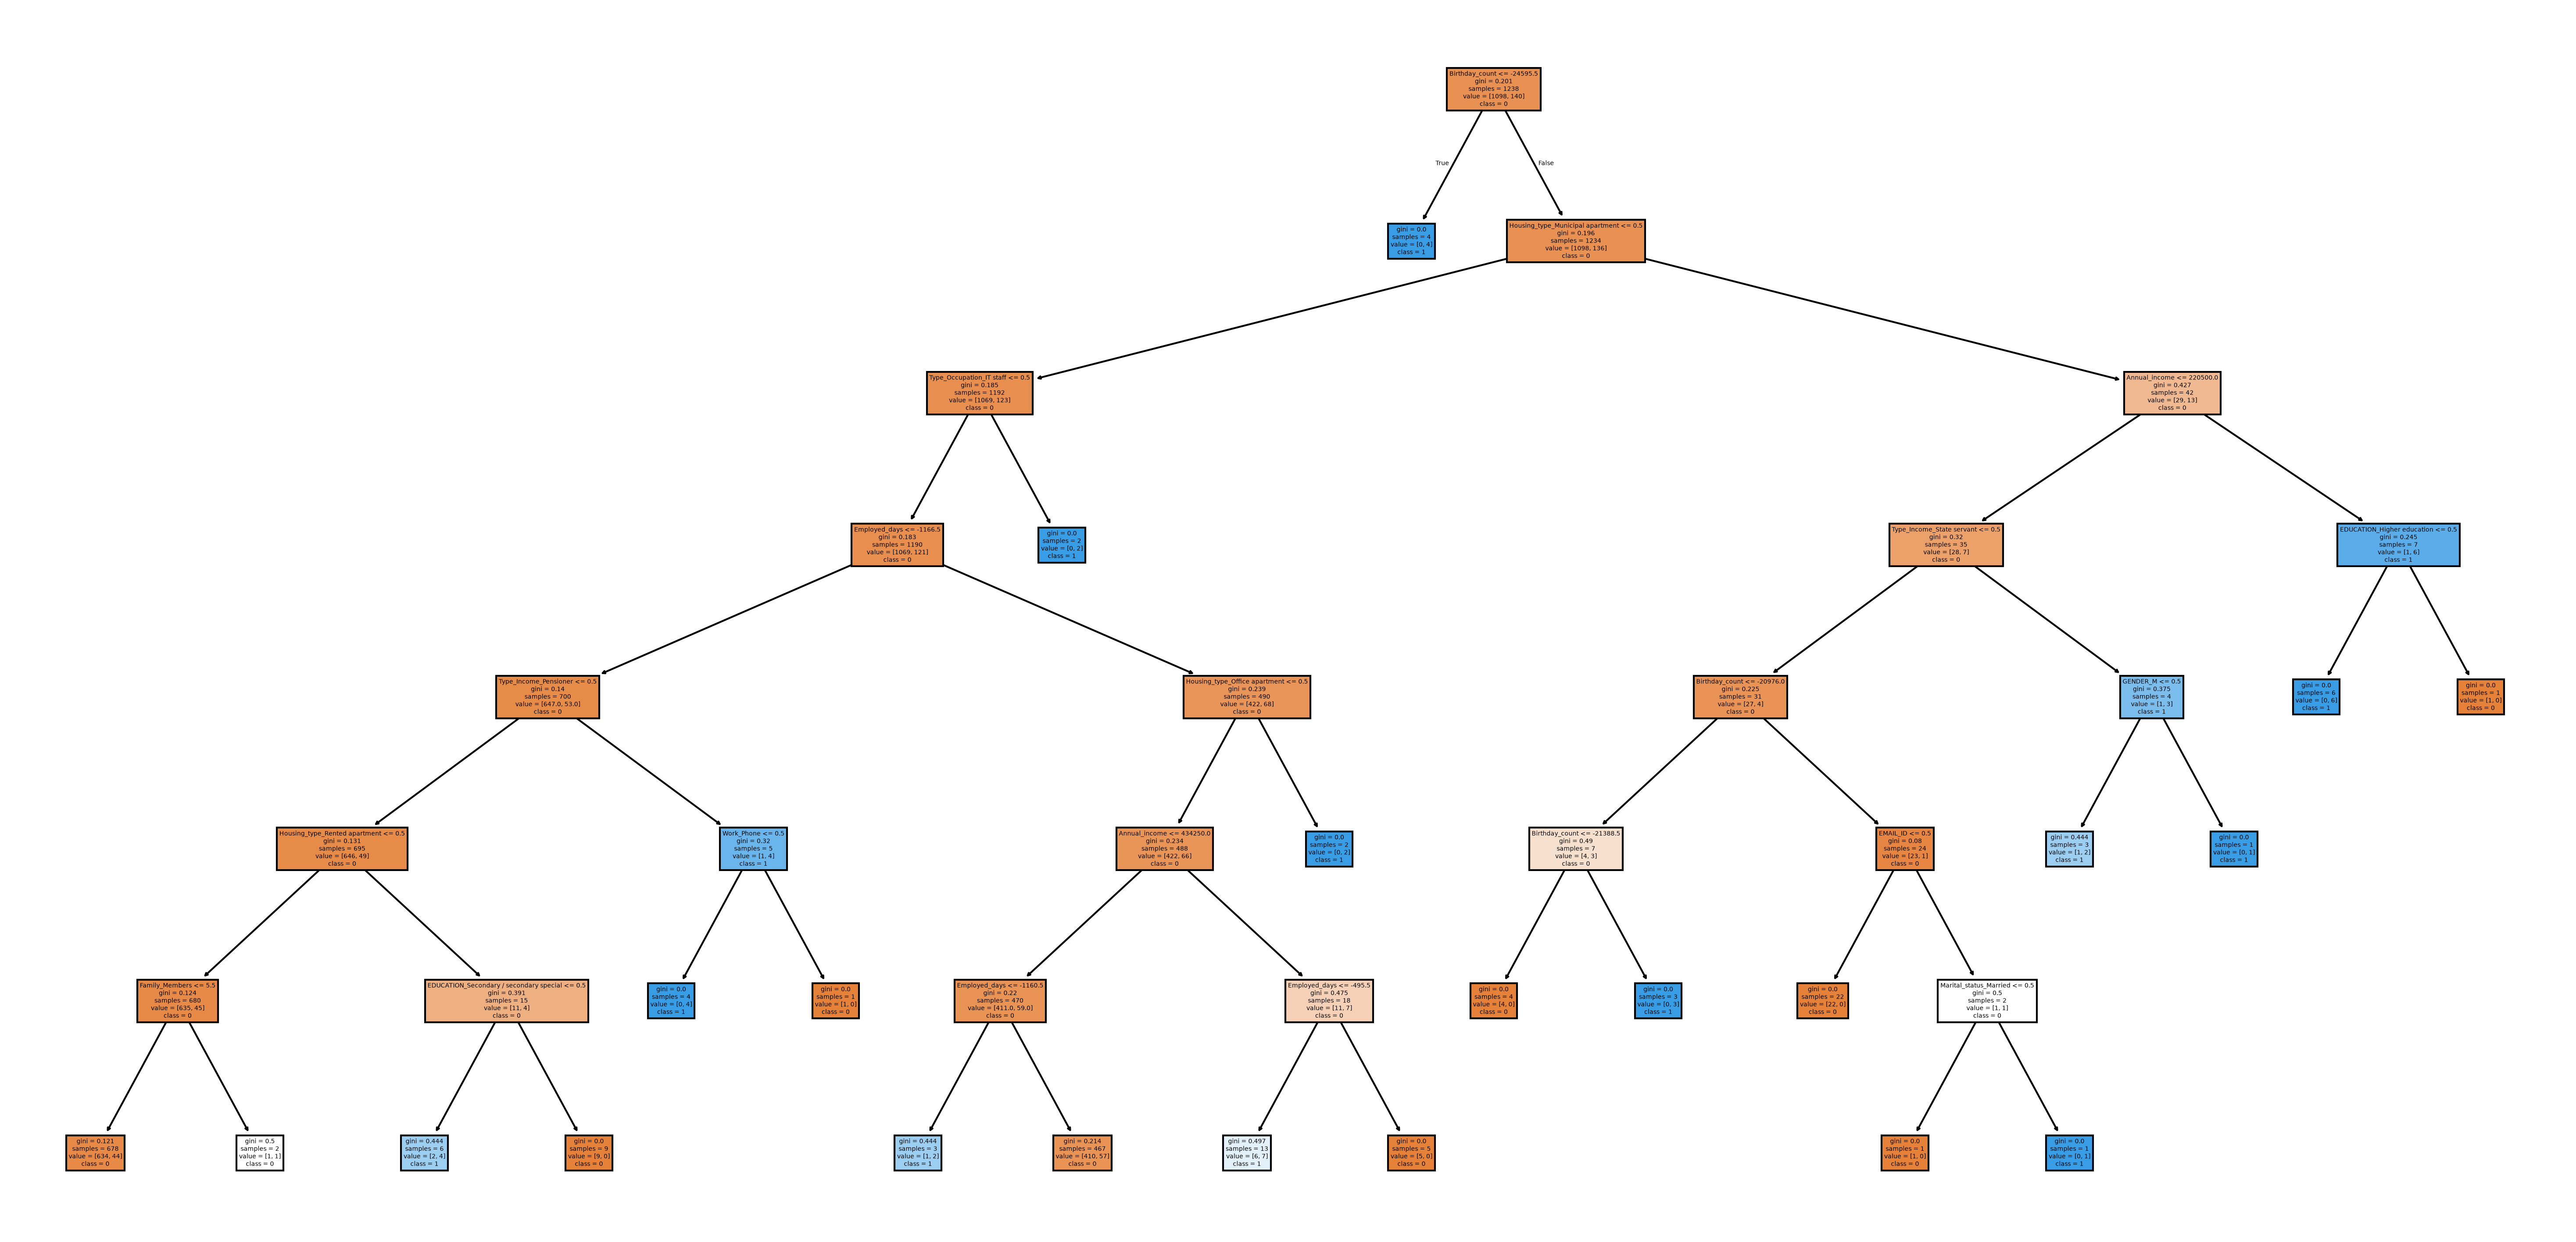

In [37]:
tree_depth_1 = DecisionTreeClassifier(
    max_depth=best_tree[0],
    random_state=42
)

tree_depth_1.fit(X_train, Y_train)

plt.figure(figsize=(25, 12), dpi=300)

plot_tree(
    tree_depth_1,
    feature_names=X.columns,
    class_names=["0", "1"],
    filled=True
)

plt.show()

---

# F метрика


In [42]:
tree_results = []

for depth in range(1, 21):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, Y_train)

    pred = model.predict(X_test)
    accuracy = f1_score(Y_test, pred)

    tree_results.append((depth, accuracy, pred))

print("Дерево:")
best_tree = max(tree_results, key=lambda x: x[1])
print(best_tree[0], " ", best_tree[1])

Дерево:
16   0.463768115942029


## Соседей

In [48]:
knn_results = []

for k in range(1, 16):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, Y_train)

    pred = model.predict(X_test_scaled)
    accuracy = f1_score(Y_test, pred)

    knn_results.append((k, accuracy, pred))

print("KNN:")
best_knn = max(knn_results, key=lambda x: x[1])
print(best_knn[0], " ", best_knn[1])

KNN:
1   0.5757575757575758


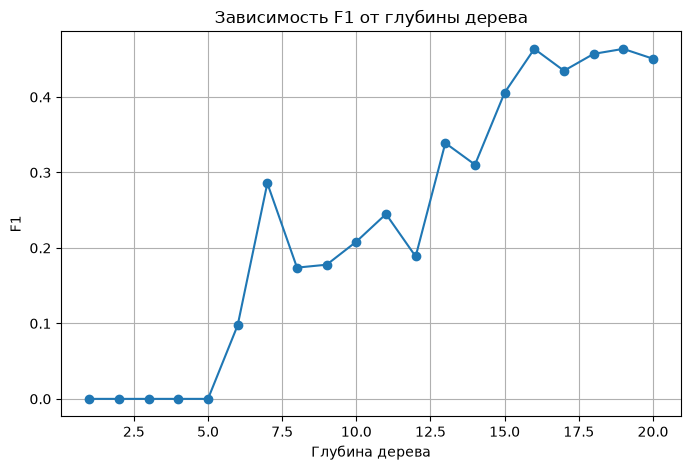

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    [x[0] for x in tree_results],
    [x[1] for x in tree_results],
    marker="o"
)

plt.xlabel("Глубина дерева")
plt.ylabel("F1")
plt.title("Зависимость F1 от глубины дерева")
plt.grid()
plt.show()

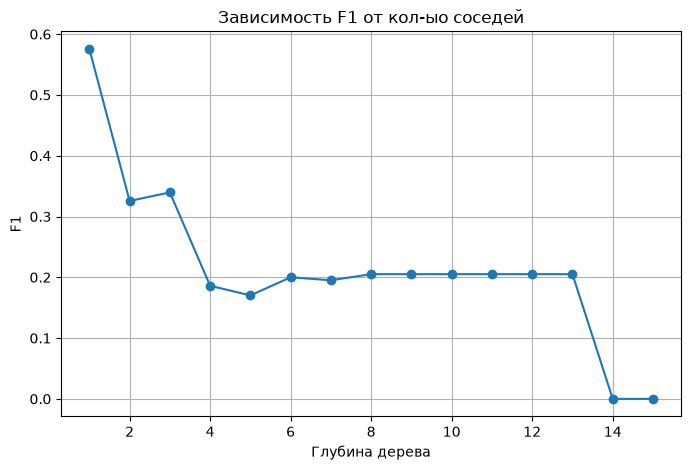

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    [x[0] for x in knn_results],
    [x[1] for x in knn_results],
    marker="o"
)

plt.xlabel("Глубина дерева")
plt.ylabel("F1")
plt.title("Зависимость F1 от кол-ыо соседей")
plt.grid()
plt.show()

Матрица ошибок дерева:
[[257  18]
 [ 19  16]]


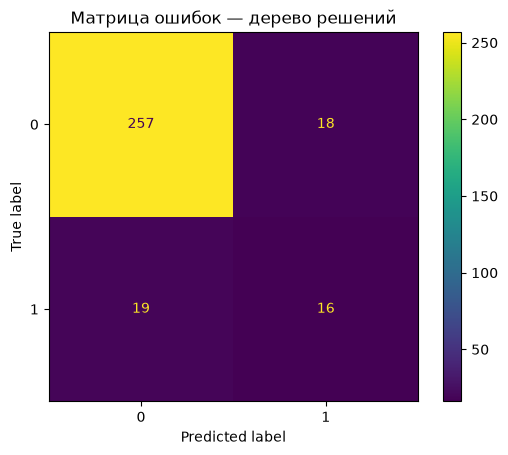

In [53]:
tree_cm = confusion_matrix(Y_test, best_tree[2])

print("Матрица ошибок дерева:")
print(tree_cm)

ConfusionMatrixDisplay(tree_cm).plot()
plt.title("Матрица ошибок — дерево решений")
plt.show()

Было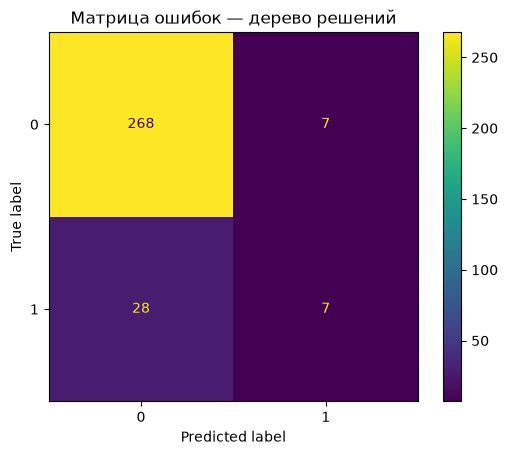

In [50]:
tree_depth_1 = DecisionTreeClassifier(
    max_depth=best_tree[0],
    random_state=42
)

tree_depth_1.fit(X_train, Y_train)

plt.figure(figsize=(50, 24), dpi=300)

plot_tree(
    tree_depth_1,
    feature_names=X.columns,
    class_names=["0", "1"],
    filled=True
)

plt.show()